# 11.4 — Netting, colateral y CSA

Cierra M11. Un **netting set** agrupa varios derivados bajo un acuerdo maestro (ISDA):
en default se liquida el NETO, no cada trade por separado. Un **CSA** (Credit Support
Annex) especifica cuándo y cuánto colateral se debe postear — con **variation margin**
(VM) actualizado periódicamente, la exposición residual que importa para CVA se reduce al
*margin period of risk* (MPOR, el tiempo entre el último re-margining y el default
efectivo) en vez de a todo el horizonte del trade.

## 0. Configuración

Portafolio de 3 swaps bajo el mismo netting set (reusa el marco de 11.1-11.3): 5Y y 2Y en
una dirección, 3Y en la dirección opuesta.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df, par_swap_rate
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

a, sigma = 0.05, 0.01
pt1 = np.arange(1.0, 6.0); K1 = par_swap_rate(nelson_siegel_df, pt1)  # 5Y
pt2 = np.arange(1.0, 4.0); K2 = par_swap_rate(nelson_siegel_df, pt2)  # 3Y, direccion opuesta
pt3 = np.arange(1.0, 3.0); K3 = par_swap_rate(nelson_siegel_df, pt3)  # 2Y, misma direccion que 1
n_paths = 100_000
check_times = np.concatenate([[0.25], np.arange(0.5, 5.0, 0.5), [4.95]])

In [2]:
def instantaneous_forward(t, eps=1e-6):
    t = max(t, 1e-6)
    return (np.log(nelson_siegel_df(t - eps)) - np.log(nelson_siegel_df(t + eps))) / (2.0 * eps)


def hull_white_bond(t, T, r_t, a, sigma):
    B = (1.0 - np.exp(-a * (T - t))) / a
    f0t = instantaneous_forward(t)
    return ((nelson_siegel_df(T) / nelson_siegel_df(t))
            * np.exp(B * f0t - sigma ** 2 / (4 * a) * B ** 2 * (1.0 - np.exp(-2 * a * t)))
            * np.exp(-B * r_t))


def swap_value(t, r_t, K, pt, a, sigma):
    remaining = pt[pt > t + 1e-9]
    if len(remaining) == 0:
        return np.zeros_like(r_t)
    tau = np.diff(np.concatenate([[t], remaining]))
    dfs = np.array([hull_white_bond(t, Ti, r_t, a, sigma) for Ti in remaining])
    return (1.0 - dfs[-1]) - K * np.sum(tau[:, None] * dfs, axis=0)


def ou(a, sigma, t, n, rng):
    var_x = sigma ** 2 / (2 * a) * (1.0 - np.exp(-2 * a * t))
    var_I = sigma ** 2 / a ** 2 * (t - 2 / a * (1 - np.exp(-a * t)) + 1 / (2 * a) * (1 - np.exp(-2 * a * t)))
    cov_xI = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    cov = np.array([[var_x, cov_xI], [cov_xI, var_I]])
    L = np.linalg.cholesky(cov)
    Z = rng.standard_normal((n, 2))
    return (Z @ L.T)[:, 0]


def short_rate(t, a, sigma, n, rng):
    x = ou(a, sigma, t, n, rng)
    alpha = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    return instantaneous_forward(t) + alpha + x

## 1. Netting: portafolio de 3 trades

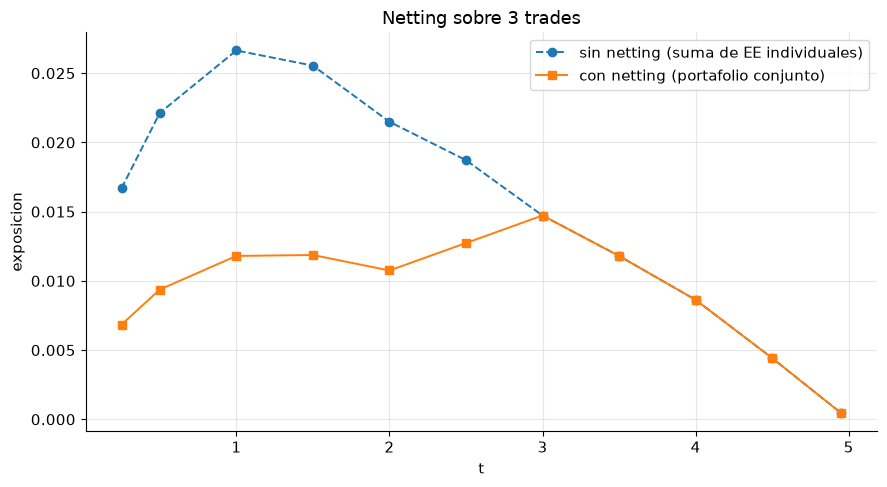

EE neteado <= suma de EE individuales, en toda la malla: True


In [3]:
EE1, EE2, EE3, EE_net = [], [], [], []
for t in check_times:
    r_t = short_rate(t, a, sigma, n_paths, rng)
    V1 = swap_value(t, r_t, K1, pt1, a, sigma)
    V2 = -swap_value(t, r_t, K2, pt2, a, sigma)  # direccion opuesta
    V3 = swap_value(t, r_t, K3, pt3, a, sigma)
    V_net = V1 + V2 + V3
    EE1.append(np.maximum(V1, 0.0).mean())
    EE2.append(np.maximum(V2, 0.0).mean())
    EE3.append(np.maximum(V3, 0.0).mean())
    EE_net.append(np.maximum(V_net, 0.0).mean())
EE1, EE2, EE3, EE_net = map(np.array, (EE1, EE2, EE3, EE_net))
EE_sum_no_netting = EE1 + EE2 + EE3

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(check_times, EE_sum_no_netting, "o--", label="sin netting (suma de EE individuales)")
ax.plot(check_times, EE_net, "s-", label="con netting (portafolio conjunto)")
ax.set_xlabel("t"); ax.set_ylabel("exposicion")
ax.set_title("Netting sobre 3 trades")
ax.legend(); fig.tight_layout(); plt.show()

netting_holds = np.all(EE_net <= EE_sum_no_netting + 1e-9)
print(f"EE neteado <= suma de EE individuales, en toda la malla: {netting_holds}")

## 2. CSA: threshold y margin period of risk (MPOR)

Con un CSA de threshold $H$, el colateral cubre el exceso de exposición sobre $H$ en la
ÚLTIMA fecha de margining — la exposición residual (la relevante para CVA) se reduce
aproximadamente a $\max(EE(t)-H,0)$ escalada por un factor que refleja el MPOR (a mayor
MPOR, más tiempo queda descubierta la volatilidad reciente antes del re-margining). Se usa
un proxy simplificado y documentado como tal: `max(EE(t)-H, 0) * mpor_factor`, donde
`mpor_factor<1` representa la fracción de la exposición que sobrevive el colateral
posteado en el último re-margining (un modelo completo de MPOR requeriría simular la
distribución de $V_{t+\text{MPOR}}-C_t$ explícitamente, fuera del alcance de este panorama).

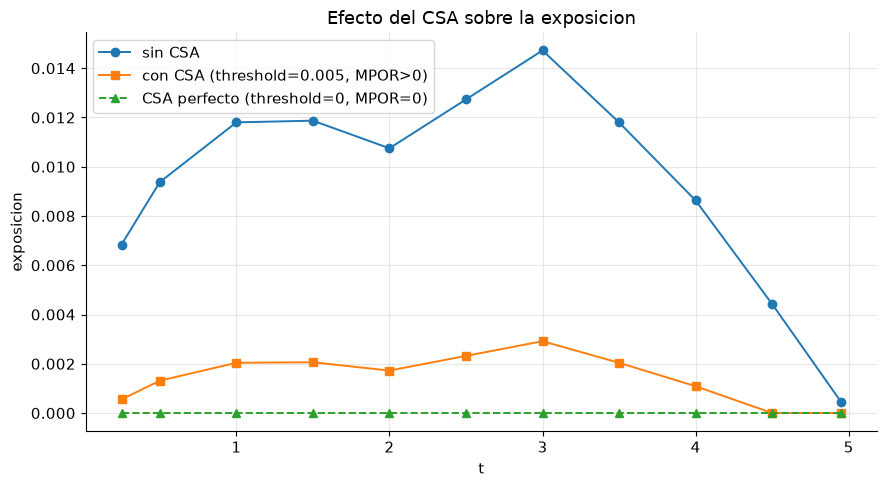

exposicion post-CSA perfecto (threshold=0, MPOR=0): max=0.00e+00


In [4]:
def csa_exposure_proxy(EE_arr, H, mpor_factor):
    return np.maximum(EE_arr - H, 0.0) * mpor_factor


threshold = 0.005
EE_post_csa_perfect = csa_exposure_proxy(EE_net, 0.0, 0.0)  # threshold=0, MPOR=0: colateral perfecto e instantaneo
EE_post_csa_realistic = csa_exposure_proxy(EE_net, threshold, 0.3)  # CSA real: threshold>0, MPOR>0

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(check_times, EE_net, "o-", label="sin CSA")
ax.plot(check_times, EE_post_csa_realistic, "s-", label=f"con CSA (threshold={threshold}, MPOR>0)")
ax.plot(check_times, EE_post_csa_perfect, "^--", label="CSA perfecto (threshold=0, MPOR=0)")
ax.set_xlabel("t"); ax.set_ylabel("exposicion")
ax.set_title("Efecto del CSA sobre la exposicion")
ax.legend(); fig.tight_layout(); plt.show()

max_residual_perfect = np.max(EE_post_csa_perfect)
print(f"exposicion post-CSA perfecto (threshold=0, MPOR=0): max={max_residual_perfect:.2e}")

### Demo — CVA con y sin CSA

In [5]:
def cva_from_EE(EE_arr, check_times, lam=0.02, R=0.4, disc_curve=nelson_siegel_df):
    surv = np.exp(-lam * check_times)
    surv_prev = np.concatenate([[1.0], surv[:-1]])
    dP_default = surv_prev - surv
    return (1.0 - R) * np.sum(EE_arr * disc_curve(check_times) * dP_default)


cva_no_csa = cva_from_EE(EE_net, check_times)
cva_with_csa = cva_from_EE(EE_post_csa_realistic, check_times)
print(f"CVA sin CSA: {cva_no_csa:.6f}")
print(f"CVA con CSA (threshold={threshold}, MPOR>0): {cva_with_csa:.6f}")

CVA sin CSA: 0.000496
CVA con CSA (threshold=0.005, MPOR>0): 0.000079


## 3. Validación

In [6]:
check1 = netting_holds
print(f"1. netting: EE(portafolio) <= suma de EE individuales: {check1}")

check2 = max_residual_perfect < 1e-9
print(f"2. exposicion post-CSA perfecto (threshold=0, MPOR=0) practicamente nula: "
      f"max={max_residual_perfect:.2e} (<1e-9? {check2})")

check3 = cva_with_csa < cva_no_csa
print(f"3. CVA con CSA < CVA sin CSA: {check3}")

assert check1
assert check2
assert check3
print("\nValidacion completa: 3/3 dentro de tolerancia.")

1. netting: EE(portafolio) <= suma de EE individuales: True
2. exposicion post-CSA perfecto (threshold=0, MPOR=0) practicamente nula: max=0.00e+00 (<1e-9? True)
3. CVA con CSA < CVA sin CSA: True

Validacion completa: 3/3 dentro de tolerancia.


## Referencias

- Gregory, J. (2015). *The xVA Challenge*, cap. 9-10 (netting y colateral), cap. 6 (CSA).
- ISDA (2013). *Standard Credit Support Annex*.